In [ ]:
import numpy as np
from IPython.display import clear_output
import time
import random

# https://www.youtube.com/watch?v=UXW2yZndl7U

In [ ]:
import os
os.path.isdir("/content/drive/MyDrive")


False

Read in the MCTS data

In [ ]:
import os, shutil
import numpy as np
import random
import time

from google.colab import drive
#drive.mount('/content/drive')

OUT_DIR = "/content/drive/MyDrive/connect4_mcts_data"
ZIP_PATH = "/content/connect4_mcts_data.zip"

os.makedirs(OUT_DIR, exist_ok=True)

print("Drive mounted. OUT_DIR exists:", os.path.exists(OUT_DIR))
print("OUT_DIR listing:", os.listdir(OUT_DIR))




Drive mounted. OUT_DIR exists: True
OUT_DIR listing: []


In [ ]:
os.listdir("/content/drive/MyDrive")


['connect4_mcts_data']

**CNN Creation**

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving connect4_mcts_dataset.npz to connect4_mcts_dataset.npz


In [ ]:
import numpy as np

DATA_PATH = "/content/connect4_mcts_dataset.npz"

data = np.load(DATA_PATH)
X = data["X"]
y = data["y"]

print("Loaded successfully")
print("X shape:", X.shape)
print("y shape:", y.shape)




Loaded successfully
X shape: (123476, 6, 7)
y shape: (123476,)


In [ ]:
import numpy as np

def pm1_to_2ch(X_pm1):
    """
    X_pm1: (N,6,7) with values in {-1,0,1}
    Returns: (N,6,7,2) float32
      channel 0 -> +1 pieces
      channel 1 -> -1 pieces
    """
    ch0 = (X_pm1 == 1).astype(np.float32)
    ch1 = (X_pm1 == -1).astype(np.float32)
    return np.stack([ch0, ch1], axis=-1)

# ---- apply conversion ----
print("Before:", X.shape, "unique:", np.unique(X))

X = pm1_to_2ch(X)

print("After:", X.shape)
print("Channel 0 unique:", np.unique(X[...,0]))
print("Channel 1 unique:", np.unique(X[...,1]))


Before: (123476, 6, 7) unique: [-1  0  1]
After: (123476, 6, 7, 2)
Channel 0 unique: [0. 1.]
Channel 1 unique: [0. 1.]


**CNN Inplementation**

**Model 4 (Production)**

We increased dropout: 0.35

In [ ]:
import tensorflow as tf
import numpy as np

SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)

X = X.astype(np.float32)
y = y.astype(np.int32)

# Deterministic shuffle for splitting
rng = np.random.default_rng(SEED)
perm = rng.permutation(len(X))
X = X[perm]
y = y[perm]

n = len(X)
n_train = int(0.80 * n)
n_val   = int(0.10 * n)

X_train, y_train = X[:n_train], y[:n_train]
X_val,   y_val   = X[n_train:n_train+n_val], y[n_train:n_train+n_val]
X_test,  y_test  = X[n_train+n_val:], y[n_train+n_val:]

print("Train:", X_train.shape, y_train.shape)
print("Val:  ", X_val.shape, y_val.shape)
print("Test: ", X_test.shape, y_test.shape)

BATCH_SIZE = 256

train_ds = (
    tf.data.Dataset.from_tensor_slices((X_train, y_train))
    .shuffle(50_000, seed=SEED, reshuffle_each_iteration=True)  # set explicitly
    .batch(BATCH_SIZE, drop_remainder=True)                     # optional
    .prefetch(tf.data.AUTOTUNE)
)

val_ds = (
    tf.data.Dataset.from_tensor_slices((X_val, y_val))
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

test_ds = (
    tf.data.Dataset.from_tensor_slices((X_test, y_test))
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

print("tf.data pipelines ready.")


Train: (98780, 6, 7, 2) (98780,)
Val:   (12347, 6, 7, 2) (12347,)
Test:  (12349, 6, 7, 2) (12349,)
tf.data pipelines ready.


In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers


def build_policy_cnn(dropout=0.25, l2=1e-4, base_filters=96):
    reg = keras.regularizers.l2(l2)

    inp = keras.Input(shape=(6, 7, 2))

    x = layers.Conv2D(base_filters, (3,3), padding="same", kernel_regularizer=reg)(inp)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)

    x = layers.Conv2D(base_filters, (3,3), padding="same", kernel_regularizer=reg)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)

    x = layers.Conv2D(base_filters // 2, (3,3), padding="same", kernel_regularizer=reg)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)

    x = layers.Dropout(dropout)(x)

    x = layers.Flatten()(x)
    x = layers.Dense(256, activation="relu", kernel_regularizer=reg)(x)
    x = layers.Dropout(dropout)(x)

    out = layers.Dense(7, activation="softmax")(x)

    model = keras.Model(inp, out)
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

# Build model
model = build_policy_cnn(dropout=0.25, l2=1e-4, base_filters=96)
model.summary()

# Callbacks
callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath="cnn2_f96_best.keras",
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=6,
        restore_best_weights=True,
        verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=3,
        min_lr=1e-5,
        verbose=1
    )
]


EPOCHS = 50

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1
)

test_loss, test_acc = model.evaluate(test_ds, verbose=1)
print(f"\nTest loss: {test_loss:.4f} | Test accuracy: {test_acc:.4f}")


model.save("cnn2_final_f96.keras")
print("Saved: cnn_best.keras (best val_loss) and cnn_final.keras (last weights)")

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 6, 7, 2)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 6, 7, 96)       │         1,824 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 6, 7, 96)       │           384 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 6, 7, 96)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 6, 7, 96)       │        83,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 6, 7, 96)       │           384 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 6, 7, 96)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 6, 7, 48)       │        41,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 6, 7, 48)       │           192 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 6, 7, 48)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 6, 7, 48)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2016)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       516,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 645,495 (2.46 MB)

 Trainable params: 645,015 (2.46 MB)

 Non-trainable params: 480 (1.88 KB)

Epoch 1/50
370/385 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.3102 - loss: 1.8448
Epoch 1: val_loss improved from inf to 1.50046, saving model to cnn2_f96_best.keras
385/385 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - accuracy: 0.3133 - loss: 1.8354 - val_accuracy: 0.4327 - val_loss: 1.5005 - learning_rate: 0.0010
Epoch 2/50
383/385 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4687 - loss: 1.3983
Epoch 2: val_loss improved from 1.50046 to 1.31054, saving model to cnn2_f96_best.keras
385/385 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.4688 - loss: 1.3981 - val_accuracy: 0.4963 - val_loss: 1.3105 - learning_rate: 0.0010
Epoch 3/50
375/385 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5105 - loss: 1.3036
Epoch 3: val_loss improved from 1.31054 to 1.22006, saving model to cnn2_f96_best.keras
385/385 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5106 - loss: 1.3032 - val_accuracy: 0.5374 - val_loss: 1.2201 - learning_rate: 0.0010
Epoch 4/50
374/385 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accu

In [ ]:
#Exporting the summary table as an excel file for report
import pandas as pd

def get_model_summary_df(model):
    rows = []

    for layer in model.layers:
        rows.append({
            "Layer Name": layer.name,
            "Layer Type": layer.__class__.__name__,
            "Output Shape": layer.output.shape,
            "Param #": layer.count_params()
        })

    return pd.DataFrame(rows)

summary_df = get_model_summary_df(model)
summary_df
summary_df.to_csv("model_summary.csv", index=False)
from google.colab import files
summary_df.to_excel("model_summary.xlsx", index=False)
files.download("model_summary.xlsx")



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

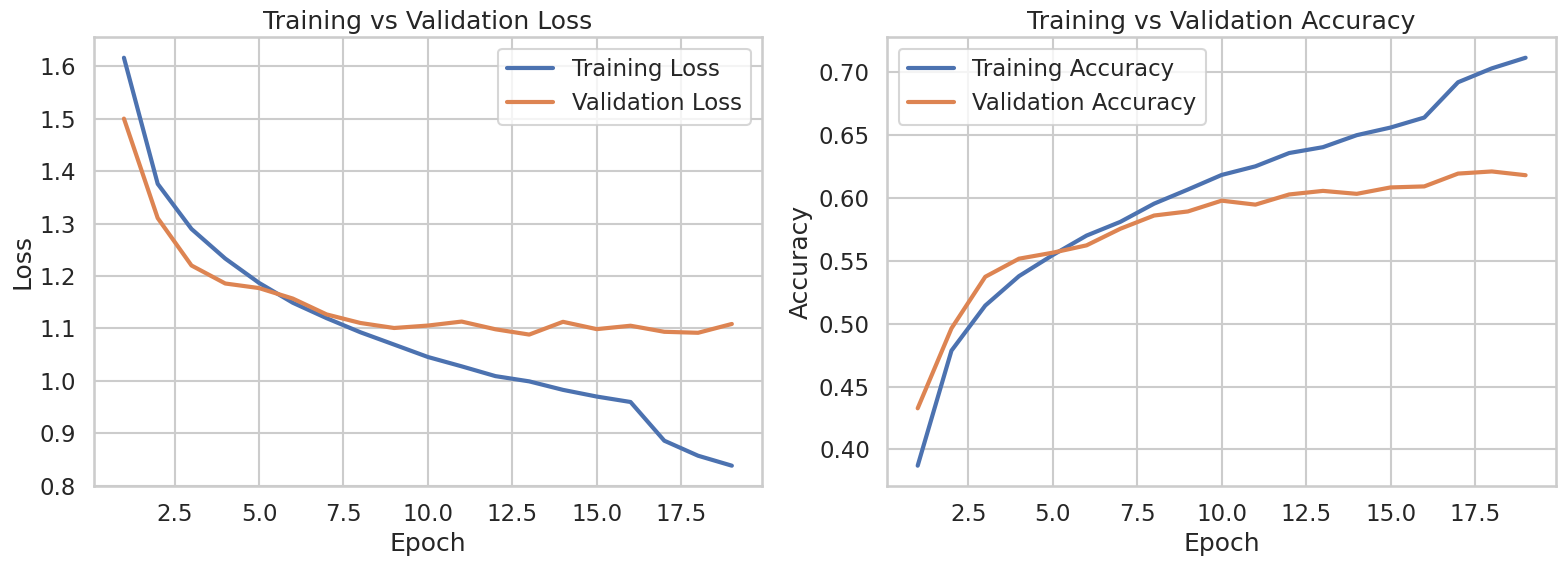

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set(style="whitegrid", context="talk")

# Extract metrics
train_loss = history.history["loss"]
val_loss   = history.history["val_loss"]
train_acc  = history.history["accuracy"]
val_acc    = history.history["val_accuracy"]

epochs = np.arange(1, len(train_loss) + 1)

# Create side-by-side figure
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Loss Plot
axes[0].plot(epochs, train_loss, label="Training Loss", linewidth=3)
axes[0].plot(epochs, val_loss, label="Validation Loss", linewidth=3)
axes[0].set_title("Training vs Validation Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()

# Accuracy Plot
axes[1].plot(epochs, train_acc, label="Training Accuracy", linewidth=3)
axes[1].plot(epochs, val_acc, label="Validation Accuracy", linewidth=3)
axes[1].set_title("Training vs Validation Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()

plt.tight_layout()
plt.show()


In [ ]:
fig.savefig("training_curves.png", dpi=300, bbox_inches="tight")

from google.colab import files
files.download("training_curves.png")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
#model.save("cnn2_final_f96.keras")
model.save("cnn2_final_f96-visuals.keras")
print("Saved: cnn2_best.keras (best val_loss) and cnn_final.keras (last weights)")

Saved: cnn2_best.keras (best val_loss) and cnn_final.keras (last weights)


**Evaluating the Model**

We can compare the model we produced with less steps to the new more powerful board positions data

Checks whether the true MCTS move appears anywhere in the model’s top-3 predictions.

Computes the fraction of successes.

This is often more meaningful in Connect 4 because:

*   Multiple moves can be near-optimal
*   MCTS labels are noisy (finite rollouts)
* Slight disagreements don’t imply bad play
* Top-1 can underestimate policy quality
* Top-3 reflects strategic agreement

We evaluate the trained model by comparing its predicted move distribution against MCTS labels, reporting both Top-1 accuracy (exact move agreement) and Top-3 accuracy (whether the MCTS move appears among the model’s three most probable actions).

In [ ]:
import tensorflow as tf
from tensorflow import keras

best = keras.models.load_model("cnn2_final_f96-visuals.keras")
best_loss, best_acc = best.evaluate(test_ds, verbose=1)
print(f"Best checkpoint -> Test loss: {best_loss:.4f} | Test accuracy: {best_acc:.4f}")


import numpy as np

# Get predictions on the full test set
y_true = np.concatenate([y for _, y in test_ds], axis=0)
probs = best.predict(test_ds, verbose=0)  # use best model
top3 = np.argsort(probs, axis=1)[:, -3:]

top1_acc = np.mean(top3[:, -1] == y_true)
top3_acc = np.mean([y_true[i] in top3[i] for i in range(len(y_true))])

print("Top-1 acc:", round(top1_acc, 4))
print("Top-3 acc:", round(top3_acc, 4))


49/49 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - accuracy: 0.6000 - loss: 1.1128
Best checkpoint -> Test loss: 1.0889 | Test accuracy: 0.6073
Top-1 acc: 0.6073
Top-3 acc: 0.9073


In [ ]:
from google.colab import files

model = files.upload()

Saving cnn_final_f96.keras to cnn_final_f96.keras


In [ ]:
import tensorflow as tf

model = tf.keras.models.load_model("cnn2_final_f96.keras")
model.save("cnnmodel2.h5")